In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pickle

In [2]:
# chargement des données d'exemple

#datafig_path = "C:/Users/Vasco Zanchi/Desktop/presentations/reunions_hebdo/figures_data_article/datafig_timeevol_example.pkl"

datafig_path = "C:/Users/Vasco Zanchi/Desktop/presentations/reunions_hebdo/figures_data_article/dict_timeevol_example.pkl"

with open(datafig_path, 'rb') as file:
    datafig = pickle.load(file)


### Figure montrant les différentes évolutions temporelles le long d'un crack

C:\Users\Vasco Zanchi\AppData\Local\Temp\ipykernel_17660\141116864.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('managua')


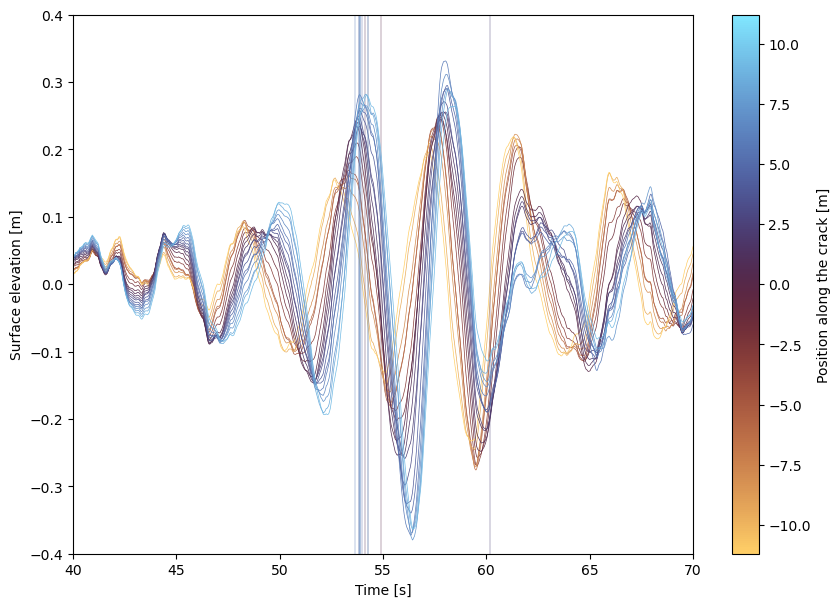

In [25]:
#print(datafig)
#plt.style.use('dark_background')
plt.rcParams['figure.facecolor'] = '1'  # Gris foncé
plt.rcParams['axes.facecolor'] = '1'

fig, ax = plt.subplots(figsize=(10,7))


facq_x = 1.25
colorvals_cassee = datafig['coord_onfracline_cassee'] * (1/facq_x)
colorvals_noncassee = datafig['coord_onfracline_noncassee'] * (1/facq_x)

cctncolors = np.concatenate((colorvals_noncassee,colorvals_cassee))
vmincolors = -np.max(np.abs(cctncolors))
vmaxcolors = np.max(np.abs(cctncolors))

#cmap = cm.get_cmap('viridis')  # ou plt.get_cmap('viridis') selon version matplotlib
cmap = cm.get_cmap('managua')

#norm = mcolors.Normalize(vmin=0, vmax=n-1)
norm = mcolors.Normalize(vmin=vmincolors, vmax=vmaxcolors)

for i in range(len(datafig['matrix_temp_evol_uz_ref_noncassee'])):
    color = cmap(norm(colorvals_noncassee[i]))
    ax.plot(datafig['tvals_sec'], datafig['matrix_temp_evol_uz_ref_noncassee'][i], color=color, alpha=1, linewidth=0.5)

n = len(datafig['matrix_temp_evol_uz'])
for i in range(n):
    color = cmap(norm(colorvals_cassee[i]))
    ax.vlines(datafig['times_frac_sec_approx'][i], -0.4, 0.4, color=color, alpha=1, linewidth=0.3)
    ax.plot(datafig['tvals_sec'], datafig['matrix_temp_evol_uz'][i], color=color, alpha=1, linewidth=0.5)


ax.set_xlim(40,70)
ax.set_ylim(-0.4,0.4)


ax.vlines(np.nan, np.nan, np.nan, linestyle='--', color='k', alpha=0.4, label='Time')

ax.set_xlabel('Time [s]')
ax.set_ylabel('Surface elevation [m]')

# Optionnel : ajouter une colorbar pour montrer la correspondance indice -> couleur
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label='Position along the crack [m]')

plt.savefig('C:/Users/Vasco Zanchi/Desktop/presentations/reunions_hebdo/figures_data_article/time_timeevol_along_crack.pdf', dpi=600)

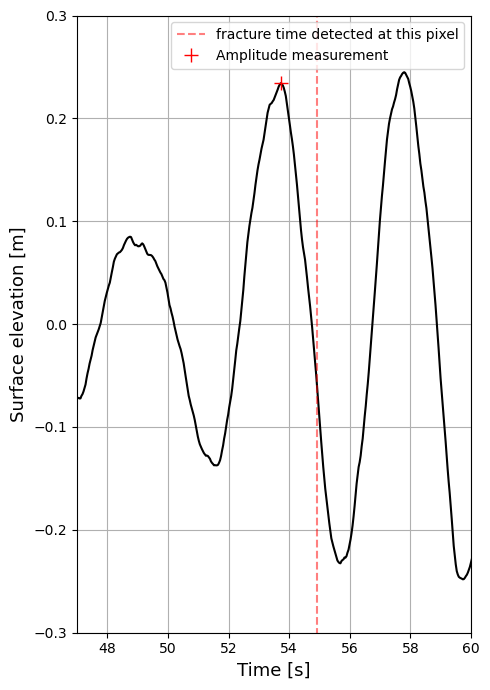

In [43]:
%matplotlib inline
plt.style.use('default')
fig, ax = plt.subplots(figsize=(5,7))
ax.plot(datafig['tvals_sec'], datafig['matrix_temp_evol_uz'][0], 'k')
ax.vlines(datafig['times_frac_sec_approx'][0], -0.4, 0.6, linestyle='--', color='r', alpha=0.5, label='fracture time detected at this pixel')

ax.plot([53.72], [0.2342], 'r+', markersize=10, label='Amplitude measurement')

ax.set_xlim(47,60)
ax.set_ylim(-0.3,0.3)
ax.set_xlabel('Time [s]', fontsize=13)
ax.set_ylabel('Surface elevation [m]', fontsize=13)
plt.tight_layout()
plt.grid()
plt.legend()
plt.savefig('C:/Users/Vasco Zanchi/Desktop/presentations/reunions_hebdo/figures_data_article/time_evol_measure_amplitudefrac.pdf', dpi=600)
plt.show()